<a href="https://colab.research.google.com/github/m00n07/mineria_de_datos/blob/main/Clasificacion_D%C3%ADgitos_Manuscritos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Metodología

## 1. Carga del dataset

In [ ]:
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.model_selection import train_test_split

# Carga
digits = datasets.load_digits()

# Visualización de ejemplo
#plt.gray()
#plt.matshow(digits.images[0])
#plt.show()

# División 80/20
X_train, X_test, y_train, y_test = train_test_split(
    digits.data, digits.target, test_size=0.2, random_state=42
)

## 2. Entrenamiento de modelos

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 1. KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

# 2. SVM
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)

# 3. Random Forest
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

RandomForestClassifier()

## 3. Evaluación

In [ ]:
models = {"KNN": knn, "SVM": svm, "Random Forest": rf}

In [ ]:
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"Exactitud de {name}: {acc:.4f}")

Exactitud de KNN: 0.9861
Exactitud de SVM: 0.9861
Exactitud de Random Forest: 0.9778


models = {"KNN": knn, "SVM": svm, "Random Forest": rf}

for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"Exactitud de {name}: {acc:.4f}")

## 4. Creación de imágenes manuscritas

In [ ]:
import numpy as np

# Ejemplo de un "1"
img_1 = [
    0, 0, 0, 12, 0, 0, 0, 0,
    0, 0, 1, 15, 0, 0, 0, 0,
    0, 0, 0, 15, 0, 0, 0, 0,
    0, 0, 0, 15, 0, 0, 0, 0,
    0, 0, 0, 15, 0, 0, 0, 0,
    0, 0, 0, 15, 0, 0, 0, 0,
    0, 0, 0, 15, 0, 0, 0, 0,
    0, 0, 0, 12, 0, 0, 0, 0
]

# Ejemplo de un "0"
img_0 = [
    0, 0, 10, 15, 15, 10, 0, 0,
    0, 10, 15, 5, 5, 15, 10, 0,
    0, 15, 5, 0, 0, 5, 15, 0,
    0, 15, 5, 0, 0, 5, 15, 0,
    0, 15, 5, 0, 0, 5, 15, 0,
    0, 10, 15, 5, 5, 15, 10, 0,
    0, 0, 10, 15, 15, 10, 0, 0,
    0, 0, 0, 0, 0, 0, 0, 0
]

# Ejemplo de un "4"
img_4 = [
    0, 0, 8, 0, 0, 8, 0, 0,
    0, 0, 8, 0, 0, 8, 0, 0,
    0, 0, 8, 0, 0, 8, 0, 0,
    0, 0, 15, 15, 15, 15, 0, 0,
    0, 0, 0, 0, 0, 8, 0, 0,
    0, 0, 0, 0, 0, 8, 0, 0,
    0, 0, 0, 0, 0, 8, 0, 0,
    0, 0, 0, 0, 0, 8, 0, 0
]

mis_digitos = [img_1, img_0, img_4]
etiquetas_reales = [1, 0, 4]

## 5. Predicción


--- Probando Dígito Real: 1 ---
Predicción KNN: 1
Predicción SVM: 1
Predicción Random Forest: 1


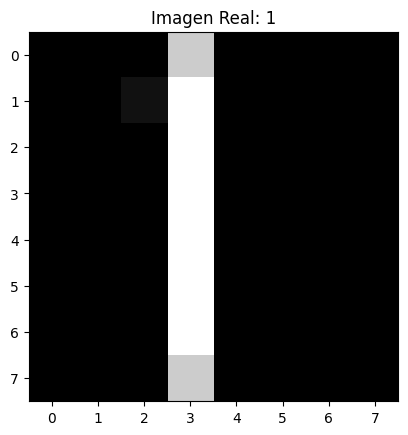


--- Probando Dígito Real: 0 ---
Predicción KNN: 0
Predicción SVM: 0
Predicción Random Forest: 0


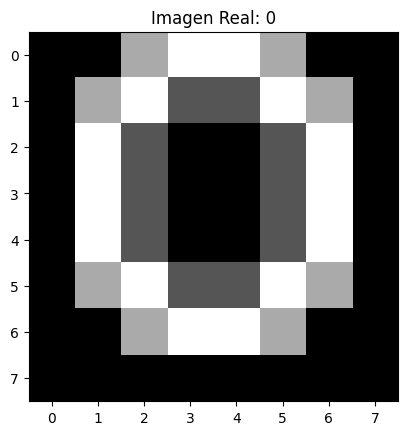


--- Probando Dígito Real: 4 ---
Predicción KNN: 9
Predicción SVM: 9
Predicción Random Forest: 9


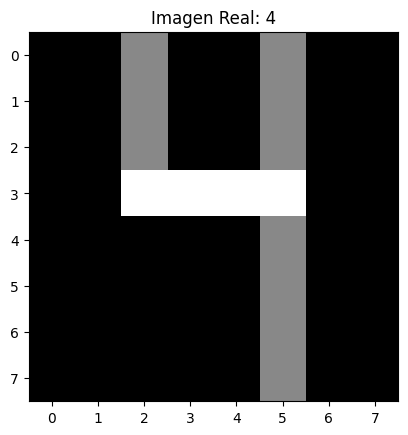

In [ ]:
for i, img in enumerate(mis_digitos):
    data_reshaped = np.array(img).reshape(1, -1)
    print(f"\n--- Probando Dígito Real: {etiquetas_reales[i]} ---")

    for name, model in models.items():
        prediccion = model.predict(data_reshaped)
        print(f"Predicción {name}: {prediccion[0]}")

    # Visualizar lo que creamos
    plt.imshow(np.array(img).reshape(8, 8), cmap='gray')
    plt.title(f"Imagen Real: {etiquetas_reales[i]}")
    plt.show()

OTRA FORMA

1

In [ ]:
from google.colab import files
from PIL import Image
import numpy as np
import io

# 1. Cargar archivos desde tu computadora
uploaded = files.upload()

mis_imagenes_procesadas = []
nombres_archivos = []

for filename in uploaded.keys():
    # Abrir la imagen cargada
    img = Image.open(io.BytesIO(uploaded[filename]))

    # Preprocesamiento:
    # a. Convertir a escala de grises ('L')
    # b. Cambiar tamaño a 8x8 píxeles (usando Lanczos para mejor calidad)
    # c. Invertir colores si es necesario (Digits usa fondo negro/0 y trazo blanco/16)
    img = img.convert('L').resize((8, 8), Image.Resampling.LANCZOS)

    # Convertir a array de numpy
    img_array = np.array(img)

    # Escalar de 0-255 a 0-16 (como el dataset original)
    # Nota: Si tu fondo es blanco y el número negro, aplica: 16 - (img_array / 16.0)
    img_array = (img_array / 16.0)

    # Aplanar a un vector de 64 elementos
    img_flat = img_array.flatten()

    mis_imagenes_procesadas.append(img_flat)
    nombres_archivos.append(filename)

print(f"\nSe han procesado {len(mis_imagenes_procesadas)} imágenes.")

Saving 4.png to 4.png
Saving 0.png to 0.png
Saving 1.png to 1.png

Se han procesado 3 imágenes.


2


Archivo: 4.png
  > Predicción KNN: 0
  > Predicción SVM: 1
  > Predicción Random Forest: 0


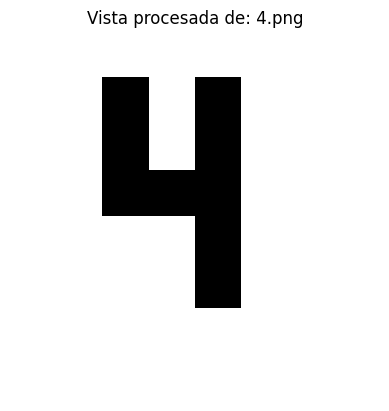


Archivo: 0.png
  > Predicción KNN: 3
  > Predicción SVM: 1
  > Predicción Random Forest: 2


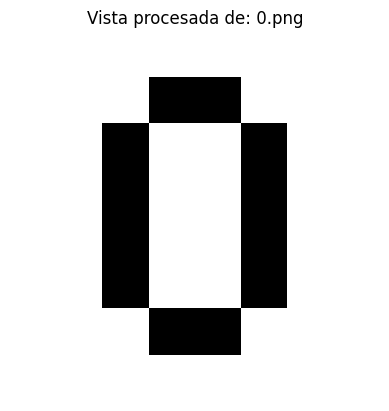


Archivo: 1.png
  > Predicción KNN: 0
  > Predicción SVM: 1
  > Predicción Random Forest: 0


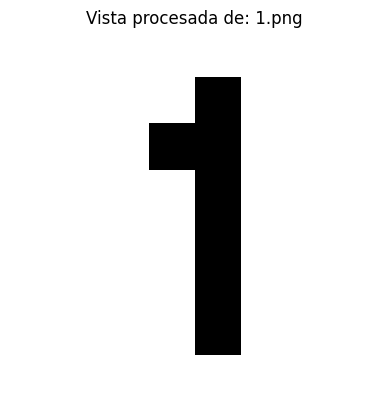

In [ ]:
# Suponiendo que tus modelos ya están entrenados (knn, svm, rf)
for i, img_data in enumerate(mis_imagenes_procesadas):
    # Preparar el dato para el modelo (1 muestra, 64 características)
    data_reshaped = img_data.reshape(1, -1)

    print(f"\nArchivo: {nombres_archivos[i]}")

    # Predicciones
    pred_knn = knn.predict(data_reshaped)[0]
    pred_svm = svm.predict(data_reshaped)[0]
    pred_rf = rf.predict(data_reshaped)[0]

    print(f"  > Predicción KNN: {pred_knn}")
    print(f"  > Predicción SVM: {pred_svm}")
    print(f"  > Predicción Random Forest: {pred_rf}")

    # Visualización de cómo el modelo "ve" tu PNG procesado
    plt.imshow(img_data.reshape(8, 8), cmap='gray')
    plt.title(f"Vista procesada de: {nombres_archivos[i]}")
    plt.axis('off')
    plt.show()

3

In [ ]:
from sklearn.metrics import accuracy_score, classification_report

# Creamos un diccionario para iterar fácilmente
models = {"KNN": knn, "SVM": svm, "Random Forest": rf}

print("--- RESULTADOS DE EVALUACIÓN (CONJUNTO DE PRUEBA) ---")
for name, model in models.items():
    preds = model.predict(X_test)
    acc = accuracy_score(y_test, preds)
    print(f"{name}: {acc:.4f} de exactitud")

# El modelo con mayor puntuación es el ganador teóricamente

--- RESULTADOS DE EVALUACIÓN (CONJUNTO DE PRUEBA) ---
KNN: 0.9861 de exactitud
SVM: 0.9861 de exactitud
Random Forest: 0.9778 de exactitud


4

In [ ]:
from google.colab import files
from PIL import Image, ImageOps
import numpy as np
import io

# Subir archivos
print("Sube tus 3 imágenes PNG (asegúrate de que sean claras):")
uploaded = files.upload()

mis_imagenes_procesadas = []
nombres_archivos = []

for filename in uploaded.keys():
    # Abrir y convertir a escala de grises
    img = Image.open(io.BytesIO(uploaded[filename])).convert('L')

    # IMPORTANTE: El dataset Digits tiene fondo NEGRO y número BLANCO.
    # Si tus dibujos son fondo blanco y número negro, debemos invertirlos:
    img = ImageOps.invert(img)

    # Redimensionar a 8x8
    img = img.resize((8, 8), Image.Resampling.LANCZOS)

    # Convertir a array y normalizar a rango 0-16
    img_array = np.array(img)
    img_scaled = (img_array / 255.0) * 16.0

    # Aplanar a 64 características
    mis_imagenes_procesadas.append(img_scaled.flatten())
    nombres_archivos.append(filename)

print(f"\nProcesamiento completado: {len(mis_imagenes_procesadas)} imágenes listas.")

Sube tus 3 imágenes PNG (asegúrate de que sean claras):


Saving 4.png to 4 (1).png
Saving 0.png to 0 (1).png
Saving 1.png to 1 (1).png

Procesamiento completado: 3 imágenes listas.


5

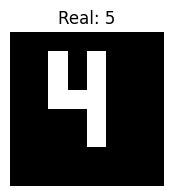

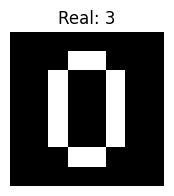

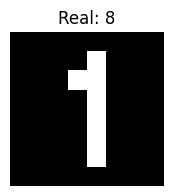


--- COMPARATIVA DE DESEMPEÑO ---
     Archivo  Etiqueta Real  Pred. KNN  Pred. SVM  Pred. RF
0  4 (1).png              5          4          1         1
1  0 (1).png              3          0          0         0
2  1 (1).png              8          1          1         1


In [ ]:
import pandas as pd

resultados = []

# Supongamos que conoces la etiqueta real de tus archivos (ej. el primer archivo es un 5, etc.)
# Puedes editar esta lista según el orden en que subas tus archivos:
etiquetas_reales = [5, 3, 8] # <--- AJUSTA ESTO SEGÚN TUS DIBUJOS

for i, img_data in enumerate(mis_imagenes_procesadas):
    data_input = img_data.reshape(1, -1)

    # Predecir con cada modelo
    p_knn = knn.predict(data_input)[0]
    p_svm = svm.predict(data_input)[0]
    p_rf = rf.predict(data_input)[0]

    # Guardar en una lista para la tabla final
    resultados.append({
        "Archivo": nombres_archivos[i],
        "Etiqueta Real": etiquetas_reales[i],
        "Pred. KNN": p_knn,
        "Pred. SVM": p_svm,
        "Pred. RF": p_rf
    })

    # Visualización rápida
    plt.figure(figsize=(2,2))
    plt.imshow(img_data.reshape(8, 8), cmap='gray')
    plt.title(f"Real: {etiquetas_reales[i]}")
    plt.axis('off')
    plt.show()

# Mostrar tabla comparativa
df_resultados = pd.DataFrame(resultados)
print("\n--- COMPARATIVA DE DESEMPEÑO ---")
print(df_resultados)